In [26]:
import kagglehub
path = kagglehub.dataset_download("anshulm257/rice-disease-dataset")

In [11]:
import os
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.transforms import functional as F
import torchvision.transforms.functional as TF
import random
from sklearn.metrics import confusion_matrix

from torchvision import transforms
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.data import TensorDataset

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torchvision import models


In [2]:
dataset_path = "/kaggle/input/rice-disease-dataset/Rice_Leaf_AUG"
selected_classes = ["Healthy Rice Leaf", "Bacterial Leaf Blight", "Brown Spot", "Leaf Blast"]

image_paths = []
image_labels = []

for idx, cls in enumerate(selected_classes):
    cls_folder = os.path.join(dataset_path, cls)
    if os.path.exists(cls_folder):
        for filename in os.listdir(cls_folder):
            if filename.endswith(".jpg"):
                image_paths.append(os.path.join(cls_folder, filename))
                image_labels.append(idx)

print(f"Total images collected: {len(image_paths)}")


Total images collected: 2569


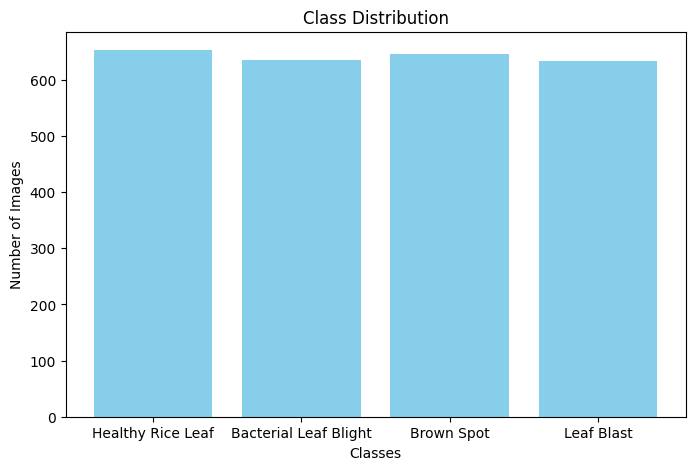

Healthy Rice Leaf: 653
Bacterial Leaf Blight: 636
Brown Spot: 646
Leaf Blast: 634


In [36]:
class_counts = Counter(image_labels)

plt.figure(figsize=(8,5))
plt.bar([selected_classes[i] for i in class_counts.keys()],
        class_counts.values(),
        color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

for cls_idx, count in class_counts.items():
    print(f"{selected_classes[cls_idx]}: {count}")


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()  
])

all_images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = transform(img)
    all_images.append(img)

all_images = torch.stack(all_images) 
all_labels = torch.tensor(image_labels)
print(f"Images tensor shape: {all_images.shape}, Labels shape: {all_labels.shape}")


Images tensor shape: torch.Size([2569, 3, 224, 224]), Labels shape: torch.Size([2569])


In [38]:
total_size = len(all_labels)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

dataset = TensorDataset(all_images, all_labels)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 1798, Validation: 385, Test: 386


In [5]:
def random_rotate(img):
    angle = random.uniform(-30, 30)
    return F.rotate(img, angle)

def random_flip(img):
    if random.random() > 0.5:
        img = F.hflip(img)
    if random.random() > 0.5:
        img = F.vflip(img)
    return img

def random_scale(img):
    scale_factor = random.uniform(0.8, 1.2)
    _, H, W = img.shape
    new_H = int(H * scale_factor)
    new_W = int(W * scale_factor)
    img = F.resize(img, [new_H, new_W])
    img = F.center_crop(img, [224, 224])
    return img

In [ ]:
train_images, train_labels = zip(*[(img, label) for img, label in train_dataset])

augmented_images = []
augmented_labels = []

for img, label in zip(train_images, train_labels):
    aug_images = [
        random_rotate(img),
        random_flip(img),
        random_scale(img)
    ]
    augmented_images.extend(aug_images)
    augmented_labels.extend([label]*3)

augmented_images = torch.stack(augmented_images)
augmented_labels = torch.tensor(augmented_labels)

train_full_images = torch.cat([torch.stack(train_images), augmented_images], dim=0)
train_full_labels = torch.cat([torch.tensor(train_labels), augmented_labels], dim=0)

print(f"Original train size: {len(train_images)}")
print(f"Augmented images: {len(augmented_images)}")
print(f"Train full dataset size: {train_full_images.shape[0]}")

Original train size: 1798
Augmented images: 5394
Train full dataset size: 7192


In [41]:
train_full_dataset = TensorDataset(train_full_images, train_full_labels)

In [ ]:
batch_size = 32

train_loader = DataLoader(train_full_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


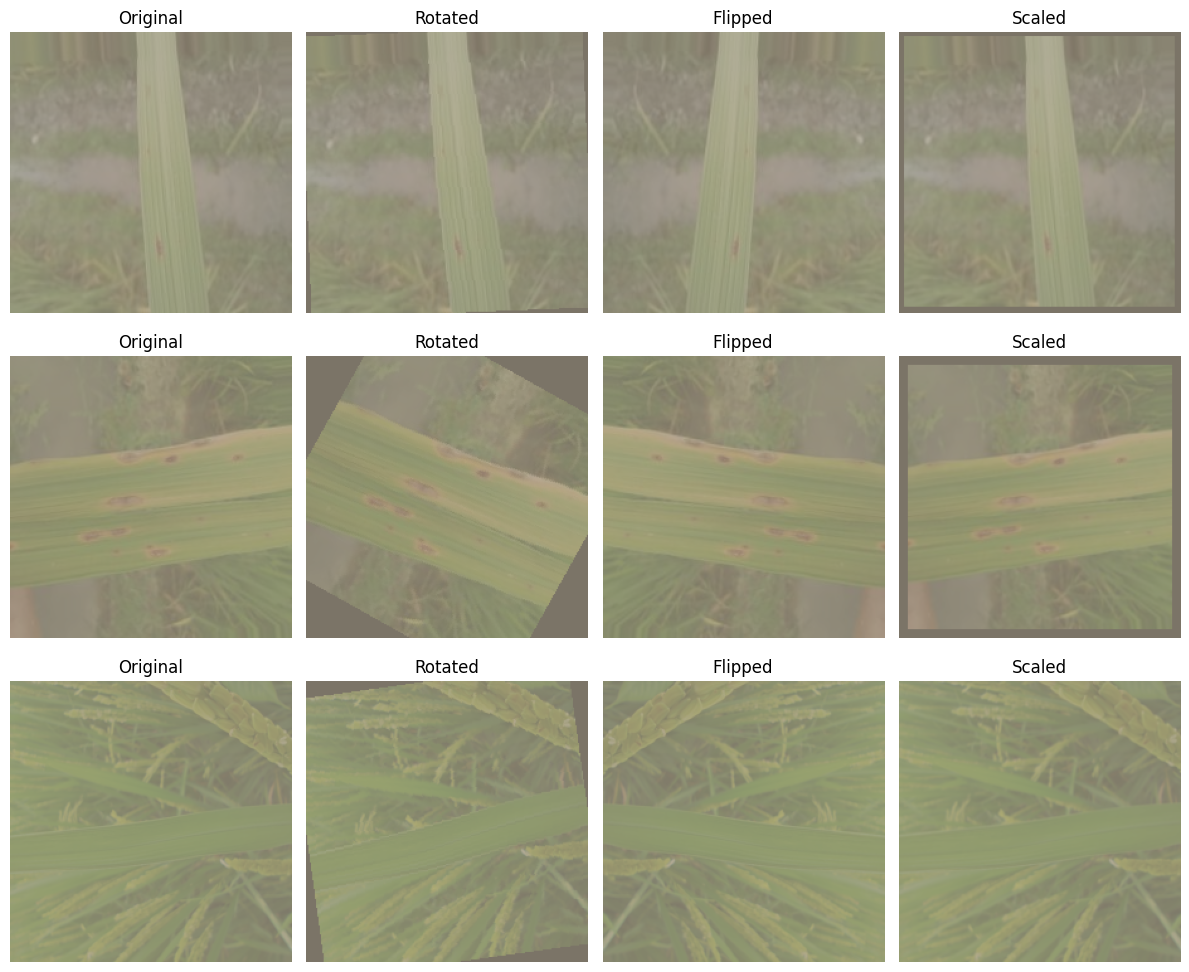

In [ ]:
indices = random.sample(range(len(train_images)), 3)

plt.figure(figsize=(12, 10))
titles = ["Original", "Rotated", "Flipped", "Scaled"]
plot_index = 1
for idx in indices:
    img = train_images[idx]     

    
    rotated = random_rotate(img)
    flipped = random_flip(img)
    scaled = random_scale(img)

    aug_list = [img, rotated, flipped, scaled]

   
    for j, aimg in enumerate(aug_list):
        plt.subplot(3, 4, plot_index)
        
        np_img = aimg.permute(1, 2, 0).cpu().numpy()
        
        np_img = np_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        np_img = np.clip(np_img, 0, 1)

        plt.imshow(np_img)
        plt.axis("off")
        plt.title(f"{titles[j]}")

        plot_index += 1

plt.tight_layout()
plt.show()


## AlexNet model

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
    
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 5 * 5, 4096),  
            nn.ReLU(inplace=True),
            
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            
            nn.Linear(4096, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) 
        x = self.classifier(x)
        return x

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [58]:
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 54, 54]          34,944
              ReLU-2           [-1, 96, 54, 54]               0
         MaxPool2d-3           [-1, 96, 26, 26]               0
            Conv2d-4          [-1, 256, 26, 26]         614,656
              ReLU-5          [-1, 256, 26, 26]               0
         MaxPool2d-6          [-1, 256, 12, 12]               0
            Conv2d-7          [-1, 384, 12, 12]         885,120
              ReLU-8          [-1, 384, 12, 12]               0
            Conv2d-9          [-1, 384, 12, 12]       1,327,488
             ReLU-10          [-1, 384, 12, 12]               0
           Conv2d-11          [-1, 256, 12, 12]         884,992
             ReLU-12          [-1, 256, 12, 12]               0
        MaxPool2d-13            [-1, 256, 5, 5]               0
          Dropout-14                 [-

In [ ]:
num_epochs = 30
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)
    
    train_loss = train_loss / total_train
    train_acc = train_correct / total_train
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)
    
    val_loss = val_loss / total_val
    val_acc = val_correct / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/30] Train Loss: 0.9951, Train Acc: 0.5360 Val Loss: 0.7154, Val Acc: 0.6623
Epoch [2/30] Train Loss: 0.6775, Train Acc: 0.7254 Val Loss: 0.5609, Val Acc: 0.7688
Epoch [3/30] Train Loss: 0.5385, Train Acc: 0.7848 Val Loss: 0.5648, Val Acc: 0.7558
Epoch [4/30] Train Loss: 0.4521, Train Acc: 0.8211 Val Loss: 0.5272, Val Acc: 0.7688
Epoch [5/30] Train Loss: 0.3403, Train Acc: 0.8700 Val Loss: 0.3052, Val Acc: 0.8831
Epoch [6/30] Train Loss: 0.3021, Train Acc: 0.8828 Val Loss: 0.2346, Val Acc: 0.9039
Epoch [7/30] Train Loss: 0.2348, Train Acc: 0.9137 Val Loss: 0.3474, Val Acc: 0.8675
Epoch [8/30] Train Loss: 0.2174, Train Acc: 0.9206 Val Loss: 0.2279, Val Acc: 0.9169
Epoch [9/30] Train Loss: 0.1520, Train Acc: 0.9462 Val Loss: 0.2014, Val Acc: 0.9195
Epoch [10/30] Train Loss: 0.1179, Train Acc: 0.9587 Val Loss: 0.2051, Val Acc: 0.9273
Epoch [11/30] Train Loss: 0.1209, Train Acc: 0.9573 Val Loss: 0.2464, Val Acc: 0.9299
Epoch [12/30] Train Loss: 0.0860, Train Acc: 0.9701 Val Loss: 0

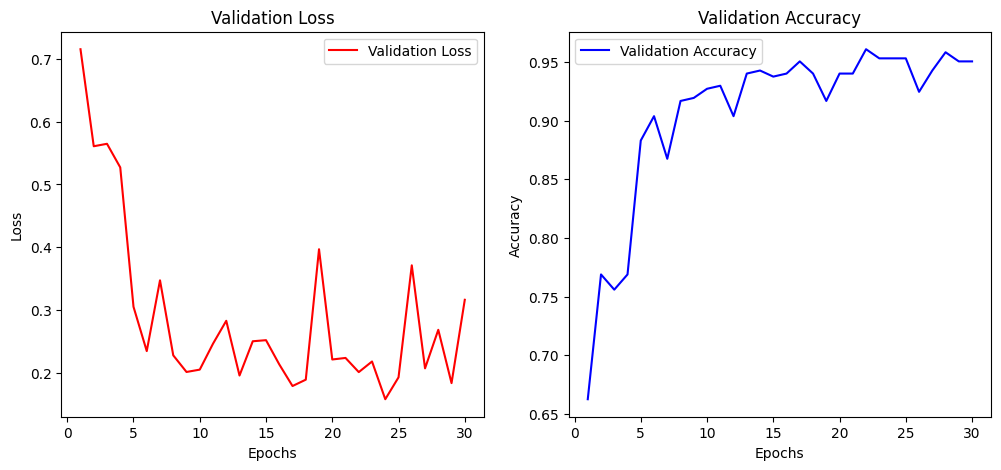

In [ ]:
epochs = range(1, len(val_losses)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, 'b-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.show()


Confusion Matrix:
[[ 98   0   0   0]
 [  0 108   4   5]
 [  1   0  75   1]
 [  1   6   7  80]]


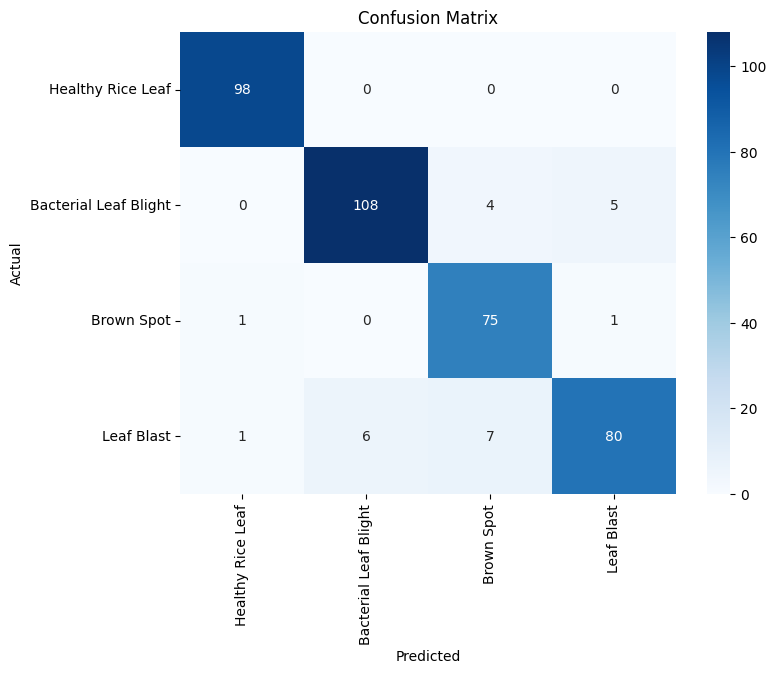

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_classes,
            yticklabels=selected_classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
num_classes = len(selected_classes)
metrics_table = []

for i in range(num_classes):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    metrics_table.append([selected_classes[i], accuracy, sensitivity, specificity])

avg_accuracy = np.mean([row[1] for row in metrics_table])
avg_sensitivity = np.mean([row[2] for row in metrics_table])
avg_specificity = np.mean([row[3] for row in metrics_table])
metrics_table.append(["Average", avg_accuracy, avg_sensitivity, avg_specificity])

import pandas as pd
df_metrics = pd.DataFrame(metrics_table, columns=["Class", "Accuracy", "Sensitivity", "Specificity"])
print(df_metrics)


                   Class  Accuracy  Sensitivity  Specificity
0      Healthy Rice Leaf  0.994819     1.000000     0.993056
1  Bacterial Leaf Blight  0.961140     0.923077     0.977695
2             Brown Spot  0.966321     0.974026     0.964401
3             Leaf Blast  0.948187     0.851064     0.979452
4                Average  0.967617     0.937042     0.978651


# Suggested model in the article

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

all_images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = transform(img)
    all_images.append(img)

all_images = torch.stack(all_images)      
all_labels = torch.tensor(image_labels)

print(f"Images tensor shape: {all_images.shape}, Labels shape: {all_labels.shape}")

Images tensor shape: torch.Size([2569, 3, 224, 224]), Labels shape: torch.Size([2569])


In [ ]:
total_size = len(all_labels)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

dataset = TensorDataset(all_images, all_labels)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

train_images, train_labels = zip(*[(img, label) for img, label in train_dataset])

augmented_images = []
augmented_labels = []

for img, label in zip(train_images, train_labels):
    aug_images = [
        random_rotate(img),
        random_flip(img),
        random_scale(img)
    ]
    augmented_images.extend(aug_images)
    augmented_labels.extend([label]*3)

augmented_images = torch.stack(augmented_images)
augmented_labels = torch.tensor(augmented_labels)

train_full_images = torch.cat([torch.stack(train_images), augmented_images], dim=0)
train_full_labels = torch.cat([torch.tensor(train_labels), augmented_labels], dim=0)

print(f"Original train size: {len(train_images)}")
print(f"Augmented images: {len(augmented_images)}")
print(f"Train full dataset size: {train_full_images.shape[0]}")

train_full_dataset = TensorDataset(train_full_images, train_full_labels)

batch_size = 32
train_loader = DataLoader(train_full_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train: 1798, Validation: 385, Test: 386
Original train size: 1798
Augmented images: 5394
Train full dataset size: 7192


In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        branch_channels = out_channels // 4  
        self.b1 = nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        self.b3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            Swish(),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1)
        )

        self.b5 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            Swish(),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(branch_channels),
            Swish(),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1)
        )

        self.bp = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.b1(x)
        b3 = self.b3(x)
        b5 = self.b5(x)
        bp = self.bp(x)
        return torch.cat([b1, b3, b5, bp], dim=1)


class ModifiedVGG19(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(vgg.features.children())[:28])

        for param in self.features.parameters():
            param.requires_grad = False

        self.extended_conv = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            Swish()
        )

        self.inception1 = InceptionBlock(in_channels=512, out_channels=256)
        self.inception2 = InceptionBlock(in_channels=256, out_channels=256)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.extended_conv(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModifiedVGG19(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [30]:
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [31]:
num_epochs = 30
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)
    
    train_loss = train_loss / total_train
    train_acc = train_correct / total_train
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)
    
    val_loss = val_loss / total_val
    val_acc = val_correct / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



Epoch [1/30] Train Loss: 0.4956, Train Acc: 0.8110 Val Loss: 0.2821, Val Acc: 0.8831
Epoch [2/30] Train Loss: 0.1923, Train Acc: 0.9326 Val Loss: 0.1392, Val Acc: 0.9455
Epoch [3/30] Train Loss: 0.0884, Train Acc: 0.9691 Val Loss: 0.1146, Val Acc: 0.9481
Epoch [4/30] Train Loss: 0.0555, Train Acc: 0.9843 Val Loss: 0.1607, Val Acc: 0.9403
Epoch [5/30] Train Loss: 0.0292, Train Acc: 0.9911 Val Loss: 0.0634, Val Acc: 0.9818
Epoch [6/30] Train Loss: 0.0165, Train Acc: 0.9961 Val Loss: 0.1000, Val Acc: 0.9662
Epoch [7/30] Train Loss: 0.0282, Train Acc: 0.9912 Val Loss: 0.0724, Val Acc: 0.9688
Epoch [8/30] Train Loss: 0.0233, Train Acc: 0.9929 Val Loss: 0.1202, Val Acc: 0.9688
Epoch [9/30] Train Loss: 0.0166, Train Acc: 0.9956 Val Loss: 0.0724, Val Acc: 0.9714
Epoch [10/30] Train Loss: 0.0194, Train Acc: 0.9937 Val Loss: 0.0865, Val Acc: 0.9792
Epoch [11/30] Train Loss: 0.0255, Train Acc: 0.9922 Val Loss: 0.1043, Val Acc: 0.9688
Epoch [12/30] Train Loss: 0.0130, Train Acc: 0.9958 Val Loss: 0

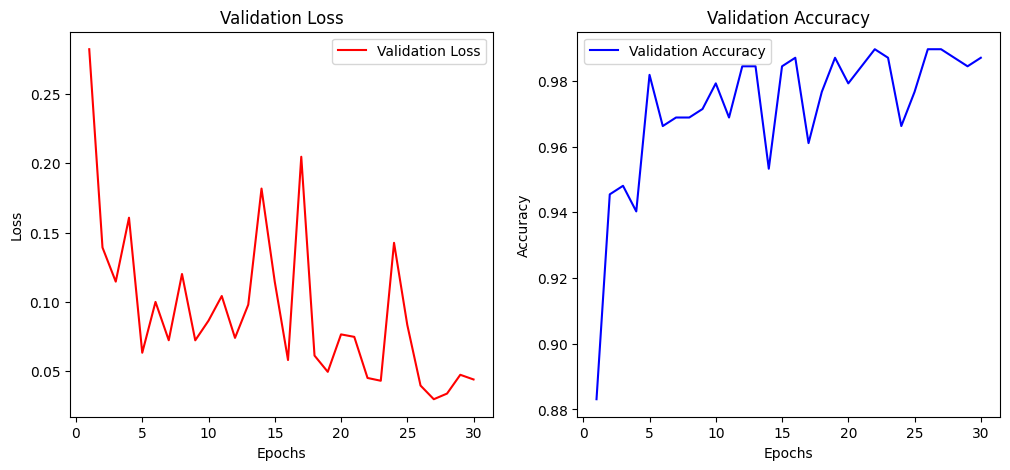

In [ ]:
epochs = range(1, len(val_losses)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, val_accuracies, 'b-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.show()

Confusion Matrix:
[[ 98   0   0   0]
 [  0 114   0   3]
 [  0   0  76   1]
 [  0   4   2  88]]


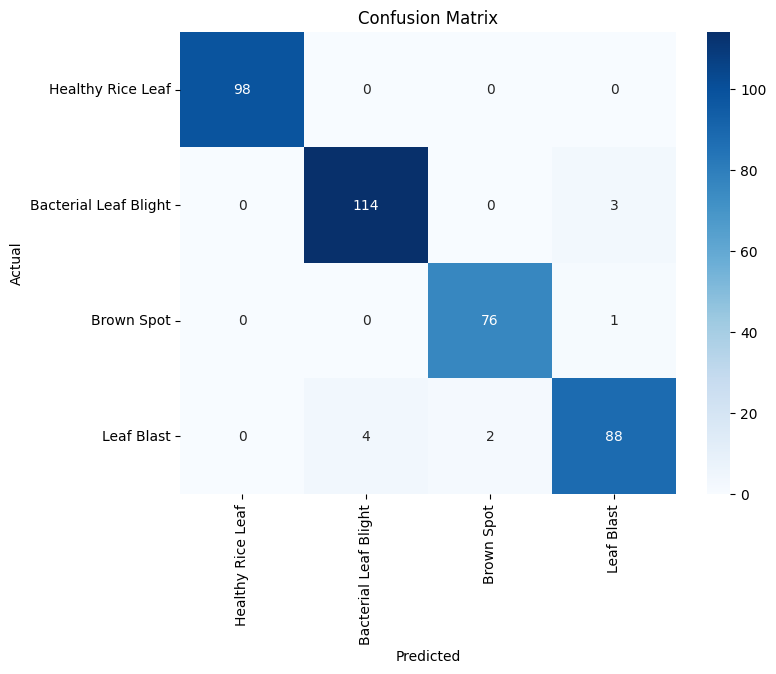

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_classes,
            yticklabels=selected_classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
num_classes = len(selected_classes)
metrics_table = []

for i in range(num_classes):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    metrics_table.append([selected_classes[i], accuracy, sensitivity, specificity])

avg_accuracy = np.mean([row[1] for row in metrics_table])
avg_sensitivity = np.mean([row[2] for row in metrics_table])
avg_specificity = np.mean([row[3] for row in metrics_table])
metrics_table.append(["Average", avg_accuracy, avg_sensitivity, avg_specificity])

import pandas as pd
df_metrics = pd.DataFrame(metrics_table, columns=["Class", "Accuracy", "Sensitivity", "Specificity"])
print(df_metrics)

                   Class  Accuracy  Sensitivity  Specificity
0      Healthy Rice Leaf  1.000000     1.000000     1.000000
1  Bacterial Leaf Blight  0.981865     0.974359     0.985130
2             Brown Spot  0.992228     0.987013     0.993528
3             Leaf Blast  0.974093     0.936170     0.986301
4                Average  0.987047     0.974386     0.991240
